In [2]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import missingno as msno

In [3]:
data_path = '/Users/danielcai/Downloads/IDXExchange Data Science roles/_/raw/california/california'
all_files = glob.glob(os.path.join(data_path, "CRMLSSold*.csv"))
selected_files = (f for f in all_files if '_filled' not in f and [ '2025' in f or '2024' in f or '2026' in f])
# to merge all the files into a single DataFrame
df = pd.concat((pd.read_csv(f, low_memory= False) for f in selected_files), ignore_index=True)
## filtering:
df = df[df['PropertyType'].str.lower() == 'residential']
df = df[df['PropertySubType'].str.lower() == 'singlefamilyresidence']

print(df.shape)
print(df.head())

(230343, 78)
       BuyerAgentAOR      ListAgentAOR           Flooring ViewYN WaterfrontYN  \
0            Arcadia           Arcadia                NaN  False          NaN   
7   CaliforniaDesert  CaliforniaDesert               Tile   True          NaN   
8             Laguna            Laguna               Wood   True          NaN   
9   PacificSouthwest  PacificSouthwest                NaN   True          NaN   
10  TheInlandGateway  TheInlandGateway  Carpet,Stone,Tile   True          NaN   

   BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0         NaN         False          1130000.0   538338723   
7         NaN          True          1995000.0  1089077716   
8         NaN          True          2340000.0  1089076111   
9         NaN          True           984000.0  1089075731   
10        NaN         False          1250000.0  1089075621   

                    ListAgentEmail  ... LotSizeDimensions  LotSizeArea  \
0              espi.bagwell@kw.com  ...              

In [4]:
# Check correlation between ListPrice and ClosePrice
print(df[['ListPrice', 'ClosePrice']].corr())

# Check how many rows have ListPrice missing
print(f"ListPrice missing: {df['ListPrice'].isnull().sum()}")
print(f"ClosePrice missing: {df['ClosePrice'].isnull().sum()}")

# Drop ListPrice to avoid data leakage
df = df.drop(columns=['ListPrice'], errors='ignore')

            ListPrice  ClosePrice
ListPrice    1.000000    0.211813
ClosePrice   0.211813    1.000000
ListPrice missing: 0
ClosePrice missing: 1


In [5]:
print (df.columns)
# since closedprice and listedprice are similar, we should be able to drop one of them.
# From the exploration notebook, we already have a list of dropped variables

cols_to_drop = [
    # Personal identifiers
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerAgentMlsId',
    'CoListAgentFirstName', 'CoListAgentLastName',
    'ListAgentFullName', 'CoListAgentLastName',
    
    # Constant state fields
    'StateOrProvince',
    
    # Redundant address
    'UnparsedAddress',
    
    # Above/Below grade (mostly empty in CA)
    'AboveGradeFinishedArea',
    
    # Brokerage names
    'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',

    # redundant price field
    'listprice',
]
df = df.drop(columns=cols_to_drop, errors='ignore')
print(f"Columns remaining: {df.shape[1]}")


Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'DaysOnMarket', 'ListOfficeName',
       'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName',
       'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId',
       'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal',
       'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear',
   

BuyerAgentAOR                     3682
ListAgentAOR                        36
Flooring                         81990
ViewYN                           20903
WaterfrontYN                    230246
BasementYN                      224687
PoolPrivateYN                    20380
OriginalListPrice                  441
ClosePrice                           1
Latitude                            29
Longitude                           29
LivingArea                         119
FireplacesTotal                 230343
AssociationFeeFrequency         172419
MLSAreaMajor                     33308
TaxAnnualAmount                 230343
ElementarySchool                199353
AttachedGarageYN                 27252
ParkingTotal                         2
BuilderName                     219771
LotSizeAcres                      3966
SubdivisionName                 149884
BuyerOfficeAOR                   14625
YearBuilt                          164
StreetNumberNumeric                281
BathroomsTotalInteger    

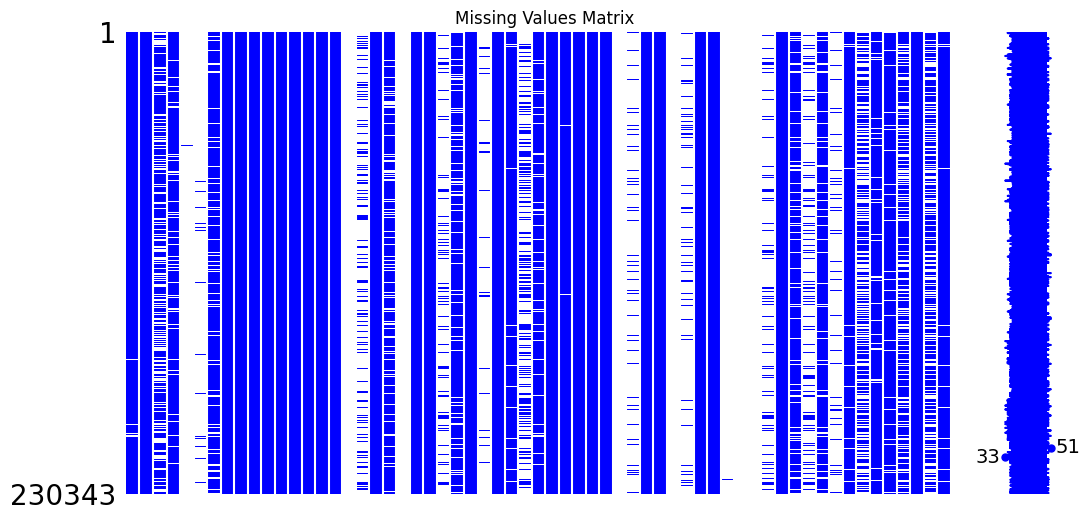

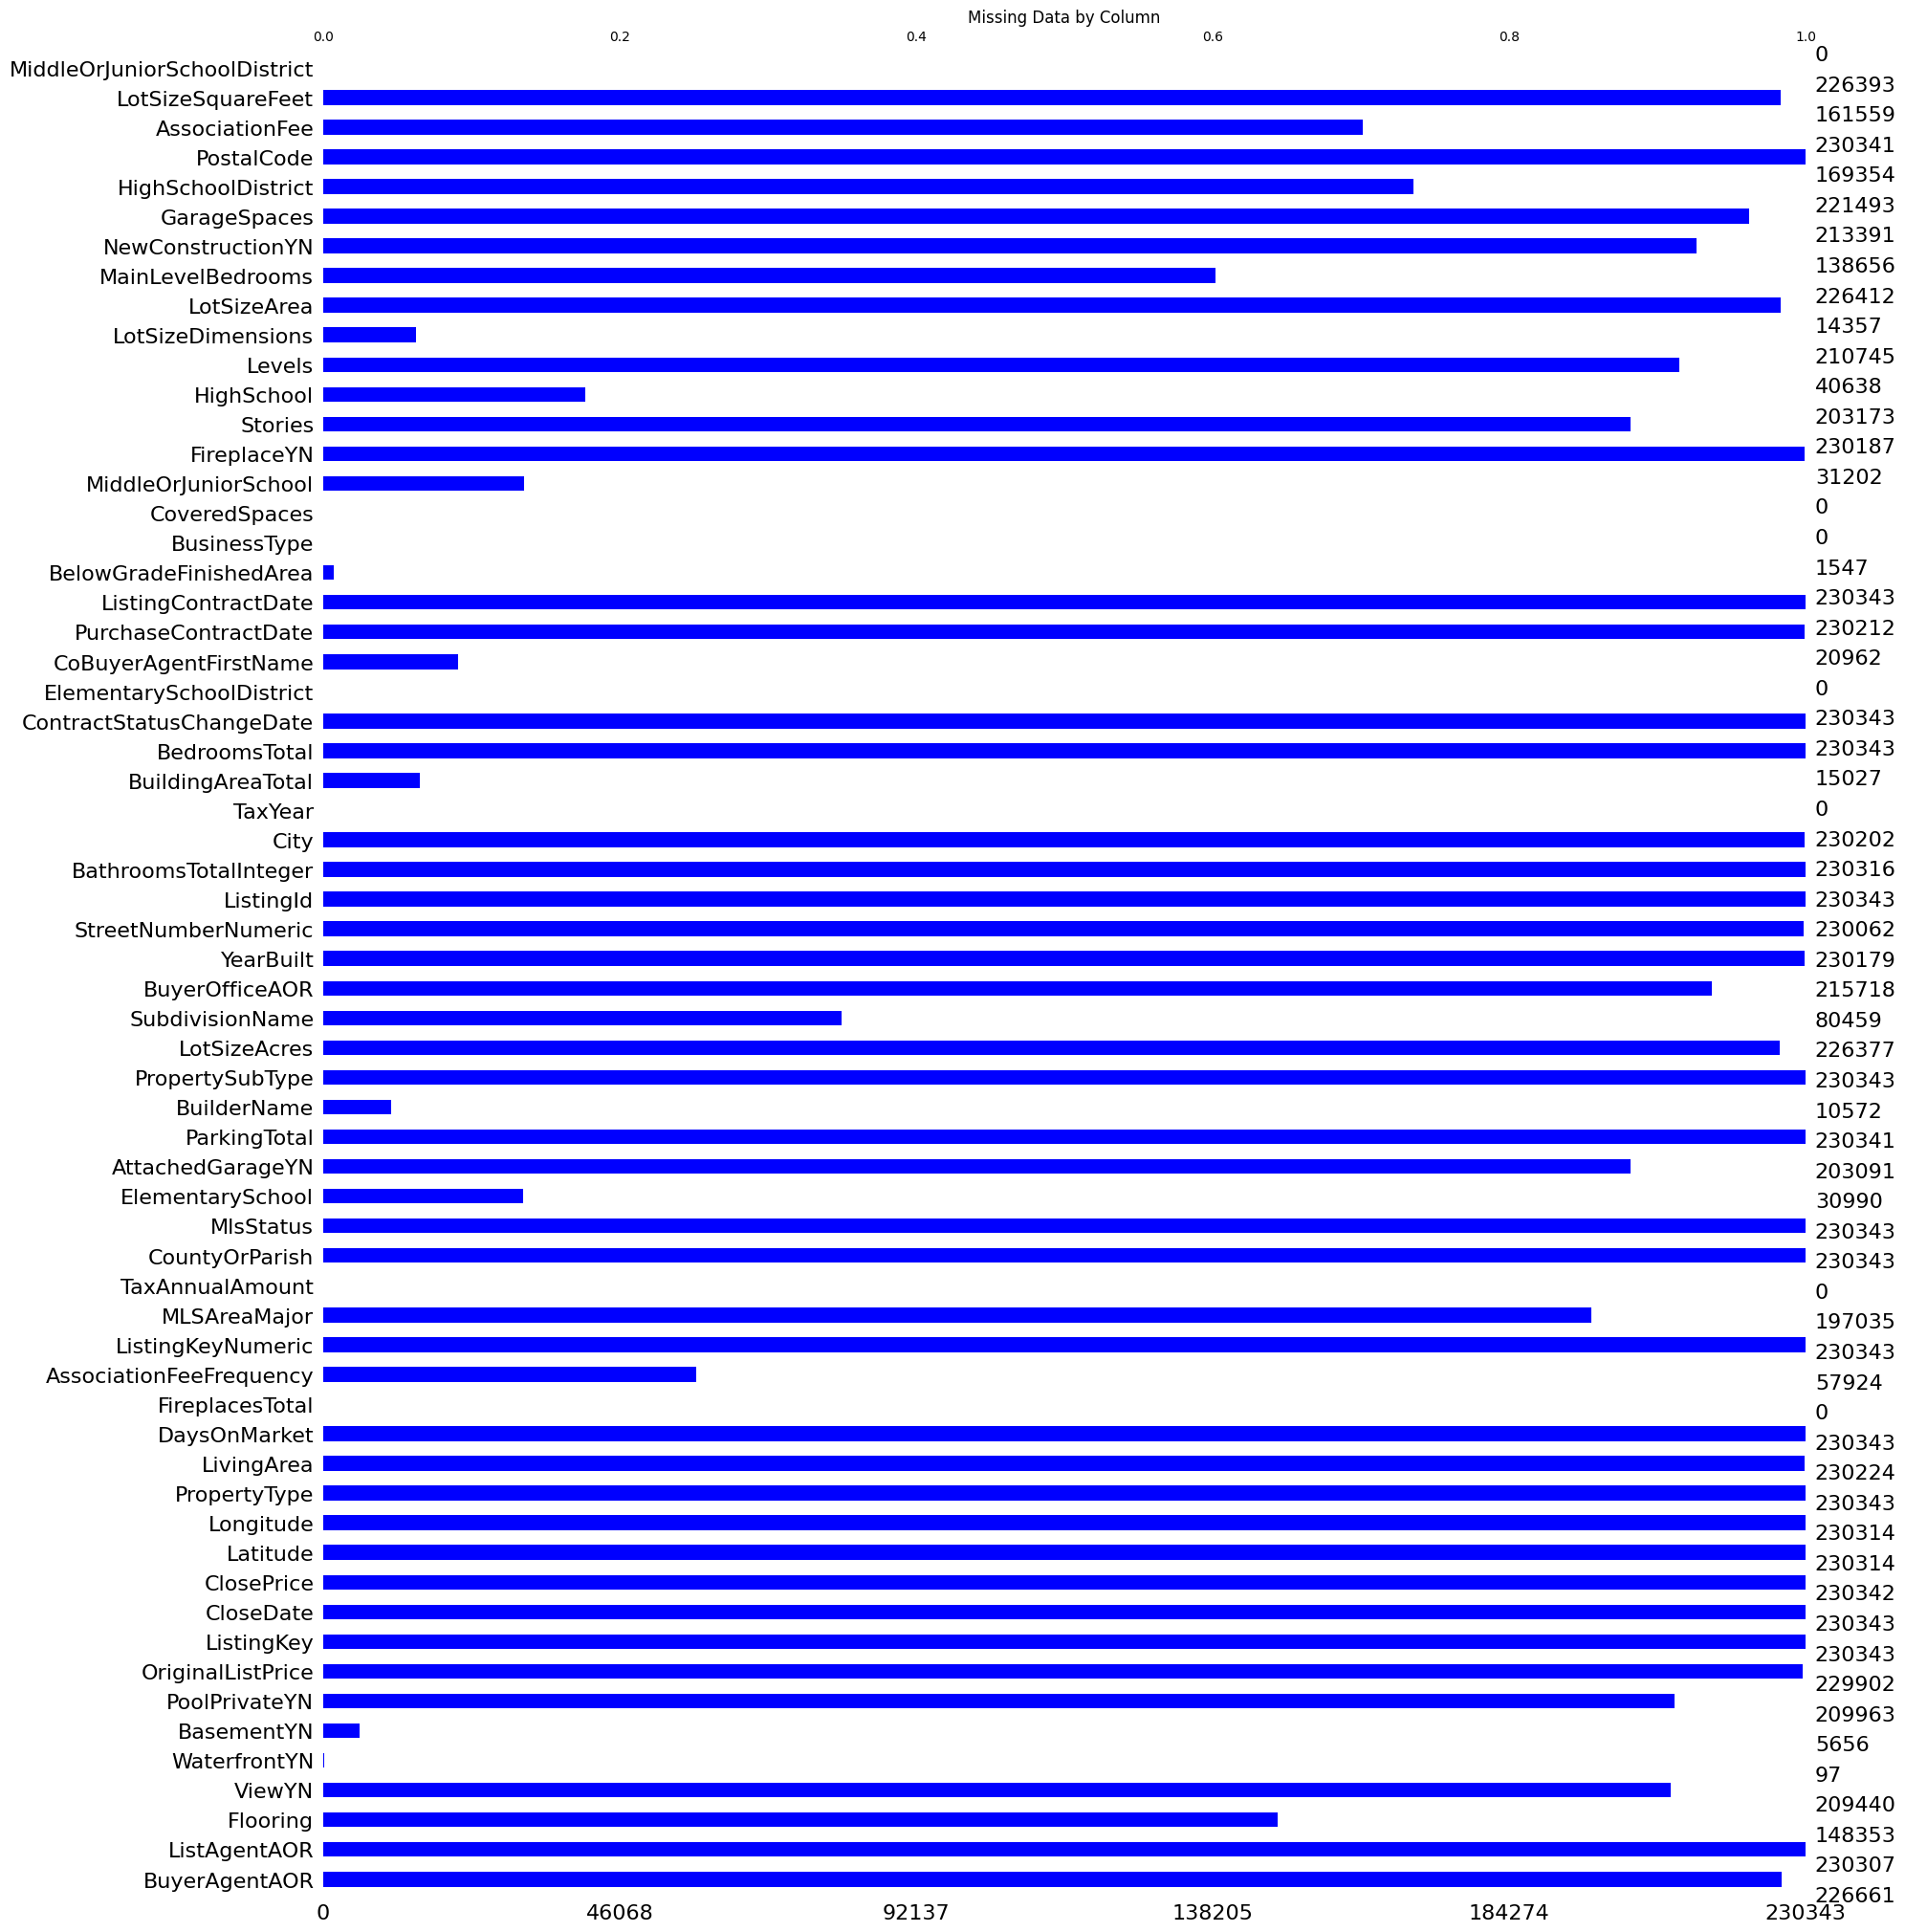

Columns remaining: 41
Remaining missing: 185456


In [6]:
# checking any missing values in the remaining columns
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
missing_pct = (missing_values / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_values, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

#Visualize missing values

msno.matrix(df, figsize=(12, 6), color = (0, 0, 1))
plt.title('Missing Values Matrix')
plt.show()


msno.bar(df, figsize=(20, 25 ), color = (0,0,1))
plt.title('Missing Data by Column')
plt.show()

#based on the missing values analysis, we can drop columns that are almost completely missing.
drop_100 = [
    'BusinessType',              # 100% — irrelevant for residential
    'ElementarySchoolDistrict',  # 100% — already have HighSchoolDistrict
    'MiddleOrJuniorSchoolDistrict', # 100% — completely empty
    'FireplacesTotal',           # 100% — completely empty
    'TaxYear',                   # 100% — completely empty
    'CoveredSpaces',             # 100% — flagged for review in your doc
    'TaxAnnualAmount',           # 100% — completely empty
]

drop_high_missing = [
    'WaterfrontYN',              # 99.95% — nearly all missing
    'BelowGradeFinishedArea',    # 99.60% — rare in CA
    'BasementYN',                # 97.61% — rare in CA
    'BuildingAreaTotal',         # 95.38% — redundant with LivingArea
    'BuilderName',               # 95.16% — extract signal first
    'LotSizeDimensions',         # 93.84% — string format, redundant
    'CoBuyerAgentFirstName',     # 91.94% — personal identifier
    'ListAgentAOR',              # 87.99% — low signal
    'BuyerAgentAOR',             # 87.99% — low signal
    'ElementarySchool',          # 85.83% — high cardinality string
    'MiddleOrJuniorSchool',      # 85.53% — high cardinality string
    'HighSchool',                # 81.79% — high cardinality string
]

drop_borderline = [
    'AssociationFeeFrequency',   # 75.84% — redundant with AssociationFee
    'SubdivisionName',           # 65.53% — high cardinality string
    'Flooring',                  # 35.93% — too vague to encode reliably
]

fill_zero = [
    'MainLevelBedrooms',   # 42.12% — missing = no main level bedrooms
    'AssociationFee',      # 30.11% — missing = no HOA
    'NewConstructionYN',   # 21.48% — missing = not new construction
]

all_drops = (
    drop_100 + 
    drop_high_missing + 
    drop_borderline
)

# Extract BuilderName signal before dropping
df['IsNewConstruction'] = (
    df['BuilderName'].notna() | 
    (df['NewConstructionYN'] == 1)
).astype(int)

df = df.drop(columns=all_drops, errors='ignore')

# Impute remaining
fill_zero = ['MainLevelBedrooms', 'AssociationFee', 'NewConstructionYN']
for col in fill_zero:
    if col in df.columns:
        df[col] = df[col].fillna(0)

df['HighSchoolDistrict'] = df['HighSchoolDistrict'].fillna('Unknown')

print(f"Columns remaining: {df.shape[1]}")
print(f"Remaining missing: {df.isnull().sum().sum()}")



In [7]:
#Train/test split

df['CloseDate'] = pd.to_datetime(df['CloseDate'])

# Check what months you have
print(df['CloseDate'].dt.to_period('M').value_counts().sort_index())
print(f"\nEarliest: {df['CloseDate'].min()}")
print(f"Latest: {df['CloseDate'].max()}")

# Identify the most recent month
latest_month = df['CloseDate'].dt.to_period('M').max()
print(f"Test month: {latest_month}")

# Split
test_df = df[df['CloseDate'].dt.to_period('M') == latest_month]
train_df = df[df['CloseDate'].dt.to_period('M') != latest_month]

print(f"Train size: {train_df.shape}")
print(f"Test size: {test_df.shape}")
print(f"Test %: {len(test_df)/len(df)*100:.1f}%")

# Drop columns not used as features
drop_from_features = [
    'CloseDate',
    'ClosePrice',        # target variable
    'ListingContractDate',
    'PurchaseContractDate',
    'ContractStatusChangeDate',
]

feature_cols = [col for col in df.columns if col not in drop_from_features]

X_train = train_df[feature_cols]
y_train = train_df['ClosePrice']

X_test = test_df[feature_cols]
y_test = test_df['ClosePrice']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Before dropping CloseDate, extract time signals
df['close_month'] = df['CloseDate'].dt.month
df['close_quarter'] = df['CloseDate'].dt.quarter
df['close_year'] = df['CloseDate'].dt.year

# Make sure test dates are all after train dates
print(f"Latest train date: {train_df['CloseDate'].max()}")
print(f"Earliest test date: {test_df['CloseDate'].min()}")



CloseDate
2024-08    12433
2024-09    10909
2024-10    12347
2024-11    10692
2024-12    10624
2025-02     8851
2025-03    10610
2025-04    11880
2025-05    11777
2025-06    11701
2025-07    12114
2025-08    11454
2025-09    11456
2025-10    12029
2025-11     9739
2025-12    10455
2026-01     7490
2026-02     8550
2026-03    11177
2026-04    12031
2026-05    12024
Freq: M, Name: count, dtype: int64

Earliest: 2024-08-01 00:00:00
Latest: 2026-05-31 00:00:00
Test month: 2026-05
Train size: (218319, 41)
Test size: (12024, 41)
Test %: 5.2%
X_train shape: (218319, 36)
X_test shape: (12024, 36)
y_train shape: (218319,)
y_test shape: (12024,)
Latest train date: 2026-04-30 00:00:00
Earliest test date: 2026-05-01 00:00:00


In [8]:
# Save cleaned data
df.to_csv('cleaned_housing.csv', index=False)
print("Saved!")

train_df.to_csv('train_housing.csv', index=False)
test_df.to_csv('test_housing.csv', index=False)
print(f"Train saved: {train_df.shape}")
print(f"Test saved: {test_df.shape}")

Saved!
Train saved: (218319, 41)
Test saved: (12024, 41)
